# Notebook 3: Quantitative Strategy Backtesting
**Description:** In this notebook, we take the predictions generated by our Differentiation Model and simulate a real-world trading strategy. We aim to evaluate the financial viability of the model by comparing its cumulative returns against a simple 'Buy and Hold' strategy of the S&P 500, using risk metrics like the Sharpe Ratio.

Load Predictions and Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# we need the csv from differentiation notebook
df_test = pd.read_csv('test_predictions.csv', parse_dates=['date']).set_index('date')

TARGET_REAL = 'sp500 close'

print("Data loaded for backtesting.")

Data loaded for backtesting.


Strategy Logic and Signal Generation

In [2]:
"""
Strategy Rules:
1. Signal: If predicted change > 0, we go LONG (+1). If < 0, we go SHORT or CASH (-1).
2. Execution: We apply 'yesterday's' prediction to 'today's' market move to avoid look-ahead bias.
"""

# 1. Calculate real market daily returns
df_test['market_returns'] = df_test[TARGET_REAL].pct_change()

# 2. Generate signals (Directional conviction)
df_test['signal'] = np.where(df_test['pred_diff'] > 0, 1, -1)

# 3. Apply the shift: We trade today based on the prediction we had at yesterday's close
df_test['strategy_returns'] = df_test['signal'].shift(1) * df_test['market_returns']

# 4. Handle the first day NaN
df_test.dropna(inplace=True)

Cumulative Performance Calculation

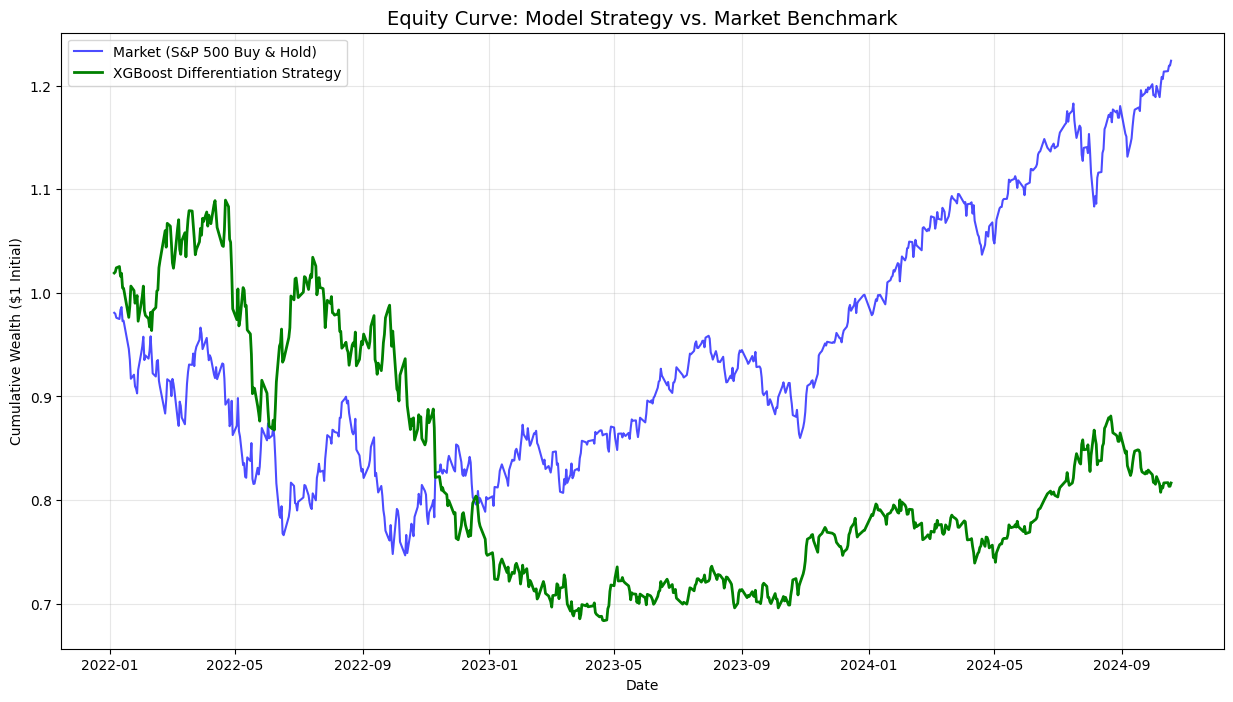

In [3]:
# Calculate cumulative growth of $1 invested
df_test['cum_market'] = (1 + df_test['market_returns']).cumprod()
df_test['cum_strategy'] = (1 + df_test['strategy_returns']).cumprod()

# Plot the equity curves
plt.figure(figsize=(15, 8))
plt.plot(df_test['cum_market'], label='Market (S&P 500 Buy & Hold)', color='blue', alpha=0.7)
plt.plot(df_test['cum_strategy'], label='XGBoost Differentiation Strategy', color='green', lw=2)
plt.title('Equity Curve: Model Strategy vs. Market Benchmark', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Wealth ($1 Initial)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Risk-Adjusted Metrics

In [4]:
# Annualized Return
total_return = df_test['cum_strategy'].iloc[-1] - 1
annualized_return = df_test['strategy_returns'].mean() * 252

# Annualized Volatility
annualized_vol = df_test['strategy_returns'].std() * np.sqrt(252)

# Sharpe Ratio (Assuming 0% risk-free rate for simplicity)
sharpe_ratio = annualized_return / annualized_vol

# Maximum Drawdown (The biggest peak-to-trough drop)
rolling_max = df_test['cum_strategy'].cummax()
drawdown = (df_test['cum_strategy'] - rolling_max) / rolling_max
max_drawdown = drawdown.min()

print(f"--- Strategy Performance Metrics ---")
print(f"Total Return (Period): {total_return:.2%}")
print(f"Annualized Return: {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_vol:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2%}")

--- Strategy Performance Metrics ---
Total Return (Period): -18.35%
Annualized Return: -5.96%
Annualized Volatility: 18.64%
Sharpe Ratio: -0.32
Max Drawdown: -37.26%


**Final Conclusions: The "Accuracy vs. Profitability" Paradox**

1. The Directional Accuracy Trap
Even though the model achieved a high Directional Accuracy (87.05%), the Total Return (-18.35%) and Sharpe Ratio (-0.32) are negative. This happens because the model is likely correct on many small, insignificant moves but fails on the "Big Days". In finance, being wrong on a single -5% crash day can wipe out the gains of ten +0.5% correct predictions.

2. Asymmetric Volatility and Drawdown
The Max Drawdown of -37.26% indicates that the strategy suffered a severe loss at some point during the 2022-2024 period. This suggests that the model struggles with "Black Swan" events or sudden market regime shifts (like rapid FED interest rate hikes) that differ from the 2010-2021 training patterns.

3. High Volatility vs. Low Conviction
With an Annualized Volatility of 18.64%, the strategy is as risky as the market itself, but without the positive drift. The negative Sharpe Ratio tells us that an investor would have been better off in a risk-free savings account than following this model's signals during this specific period.

4. Final Verdict & Future Improvements

    - Why Notebook 1 failed: It couldn't handle new price levels (Extrapolation problem).

    - Why Notebook 2 was better but not perfect: It followed the trend but lacked "Magnitude Awareness." It knew where the market was going, but not how hard it would move.

    - Future Work: To fix this, we should include Volatility indicators (like VIX) and a Position Sizing logic (trading more when the model is very confident and less when it's not).

**Technical Summary of Time Series Handling:**
The transition from absolute price forecasting to differentiated returns successfully addressed the extrapolation limits of XGBoost. However, the negative financial results highlight a common challenge in time series data management: Heteroscedasticity (variable variance over time). While the model mastered the directional trend, the variance in error magnitude suggests that further feature engineering on volatility indicators is required to achieve a robust predictive system.